# UIS Segmentation


**Steps:**
1. Install dependencies
2. Upload your image
3. Initialize the LangSAM model (first run downloads model weights, can take a few minutes)
4. Set a text prompt and run segmentation
5. Visualize and export results


## 1. Install dependencies

In [ ]:
%pip install -q segment-geospatial groundingdino-py deepforest "transformers<5"


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("WARNING: no GPU detected. Go to Runtime -> Change runtime type -> GPU, then rerun this cell.")


GPU available: True


## 2. Point to your image in Google Drive


In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Set this to the path of your file inside Drive.
# Tip: in the Colab file browser (left sidebar), navigate to the file under
# "drive", right-click it, and choose "Copy path" to get this exact string.
image_path = "/content/drive/MyDrive/UIS_Buildings_Fields_Clipped.tif"  # @param {type:"string"}

import os
assert os.path.isfile(image_path), f"File not found: {image_path} -- double check the path above"
print(f"Using image: {image_path} ({os.path.getsize(image_path) / 1e6:.1f} MB)")


Using image: /content/drive/MyDrive/UIS_Buildings_Fields_Clipped.tif (540.1 MB)


## 3. Initialize LangSAM



In [ ]:
from samgeo.text_sam import LangSAM

sam = LangSAM()


final text_encoder_type: bert-base-uncased


In [ ]:
# @title Segmentation parameters { run: "auto" }

class_prompts = ["tree"]  # @param {type:"raw"}
box_threshold = 0.26  # @param {type:"slider", min:0.0, max:1.0, step:0.01}
text_threshold = 0.31  # @param {type:"slider", min:0.0, max:1.0, step:0.01}
tile_size = 1152 # @param {"type":"slider","min":256,"max":2000,"step":64}
tile_overlap = 64  # @param {type:"integer"}
tiles_dir = "/content/tiles"  # @param {type:"string"}
masks_root_dir = "/content/masks"  # @param {type:"string"}
preview_max_size = 1500  # @param {type:"slider", min:500, max:4000, step:100}


In [ ]:
# @title Crop / downsample parameters { run: "auto" }
# Leave all four as None to keep the full extent (no cropping).
crop_min_lon = None  # @param {type:"raw"}
crop_min_lat = None  # @param {type:"raw"}
crop_max_lon = None  # @param {type:"raw"}
crop_max_lat = None  # @param {type:"raw"}

# 1.0 = full resolution, 0.5 = half width/height (a quarter of the pixels), etc.
downsample_factor = 0.8  # @param {type:"slider", min:0.1, max:1.0, step:0.05}

import rasterio
from rasterio.enums import Resampling
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds as window_from_bounds

processed_image_path = "/content/processed_image.tif"
have_crop = None not in (crop_min_lon, crop_min_lat, crop_max_lon, crop_max_lat)

with rasterio.open(image_path) as src:
    profile = src.profile.copy()

    if have_crop:
        # crop bounds are given in lat/lon (EPSG:4326); reproject into the source's own CRS
        left, bottom, right, top = transform_bounds(
            "EPSG:4326", src.crs, crop_min_lon, crop_min_lat, crop_max_lon, crop_max_lat
        )
        window = window_from_bounds(left, bottom, right, top, src.transform)
        src_width, src_height = int(window.width), int(window.height)
    else:
        left, bottom, right, top = src.bounds
        window = None
        src_width, src_height = src.width, src.height

    out_width = max(1, int(src_width * downsample_factor))
    out_height = max(1, int(src_height * downsample_factor))

    data = src.read(
        window=window,
        out_shape=(src.count, out_height, out_width),
        resampling=Resampling.average,
    )

    out_transform = transform_from_bounds(left, bottom, right, top, out_width, out_height)
    profile.update(height=out_height, width=out_width, transform=out_transform)

    with rasterio.open(processed_image_path, "w", **profile) as dst:
        dst.write(data)

    print(f"Source: {src_width} x {src_height} px  ->  Processed: {out_width} x {out_height} px "
          f"({(out_width * out_height) / (src_width * src_height):.1%} of original pixel count)")

image_path = processed_image_path  # everything below now uses the cropped/downsampled version
print(f"image_path now points to: {image_path}")


Source: 15638 x 8634 px  ->  Processed: 12510 x 6907 px (64.0% of original pixel count)
image_path now points to: /content/processed_image.tif


In [ ]:
from samgeo.common import split_raster

# Break the image into (tile_size x tile_size) tiles so each one fits comfortably in GPU memory.

split_raster(image_path, out_dir=tiles_dir, tile_size=(tile_size, tile_size), overlap=tile_overlap)



=== Segmenting: 'tree' ===
Processing image 01 of 84: /content/tiles/tile_0_0.tif...
Processing image 02 of 84: /content/tiles/tile_0_1.tif...
Processing image 03 of 84: /content/tiles/tile_0_2.tif...
Processing image 04 of 84: /content/tiles/tile_0_3.tif...
Processing image 05 of 84: /content/tiles/tile_0_4.tif...
Processing image 06 of 84: /content/tiles/tile_0_5.tif...
Processing image 07 of 84: /content/tiles/tile_0_6.tif...
Processing image 08 of 84: /content/tiles/tile_10_0.tif...
Processing image 09 of 84: /content/tiles/tile_10_1.tif...
Processing image 10 of 84: /content/tiles/tile_10_2.tif...
No objects found in the image.
Processing image 11 of 84: /content/tiles/tile_10_3.tif...
Processing image 12 of 84: /content/tiles/tile_10_4.tif...
Processing image 13 of 84: /content/tiles/tile_10_5.tif...
Processing image 14 of 84: /content/tiles/tile_10_6.tif...
Processing image 15 of 84: /content/tiles/tile_11_0.tif...
Processing image 16 of 84: /content/tiles/tile_11_1.tif...
Proc

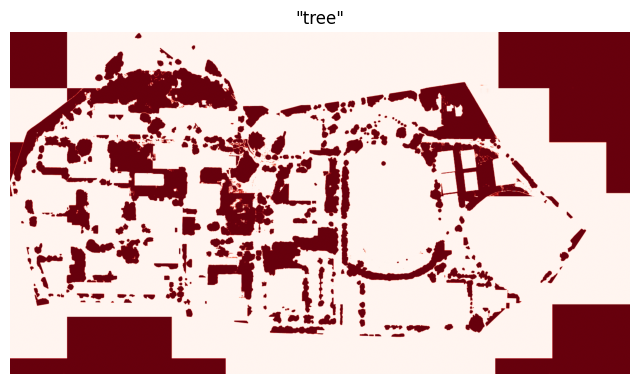

Saved vector output for 'tree' to /content/masks/tree/merged.gpkg

Done. Mask paths:
  tree: /content/masks/tree/merged.tif


In [ ]:
import gc
import os

import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import torch

from samgeo.common import raster_to_vector


def read_downsampled(path, max_size, indexes=None):
    """Read a raster at a reduced resolution directly from disk (never loads full-res data)."""
    with rasterio.open(path) as src:
        h, w = src.height, src.width
        scale = min(1.0, max_size / max(h, w))
        out_h, out_w = max(1, int(h * scale)), max(1, int(w * scale))
        n_bands = len(indexes) if indexes else src.count
        data = src.read(
            indexes=indexes,
            out_shape=(n_bands, out_h, out_w),
            resampling=Resampling.average,
        )
    return data



img_preview = read_downsampled(image_path, preview_max_size, indexes=[1, 2, 3])
img_preview = np.transpose(img_preview, (1, 2, 0))

mask_paths = {}
vector_paths = {}

for class_prompt in class_prompts:
    print(f"\n=== Segmenting: {class_prompt!r} ===")
    safe_name = class_prompt.replace(" ", "_").replace(".", "")
    class_masks_dir = os.path.join(masks_root_dir, safe_name)

    # 1. Predict (writes a full-resolution merged.tif -- never held in memory here)
    sam.predict_batch(
        images=tiles_dir,
        out_dir=class_masks_dir,
        text_prompt=class_prompt,
        box_threshold=box_threshold,
        text_threshold=text_threshold,
        mask_multiplier=255,
        dtype="uint8",
        merge=True,
        verbose=True,
    )
    mask_path = os.path.join(class_masks_dir, "merged.tif")
    mask_paths[class_prompt] = mask_path

    # 2. Preview at reduced resolution only, then release it immediately
    mask_preview = read_downsampled(mask_path, preview_max_size, indexes=[1])[0]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img_preview)
    ax.imshow(mask_preview, cmap="Reds", alpha=np.where(mask_preview > 0, 0.6, 0.0))
    ax.set_title(f'"{class_prompt}"')
    ax.axis("off")
    plt.show()
    plt.close(fig)
    del mask_preview, fig, ax

    # 3. Vector export (only meaningful for georeferenced inputs)
    vector_path = mask_path.replace(".tif", ".gpkg")
    try:
        raster_to_vector(mask_path, vector_path)
        vector_paths[class_prompt] = vector_path
        print(f"Saved vector output for {class_prompt!r} to {vector_path}")
    except Exception as e:
        print(f"Skipping vector export for {class_prompt!r} -- likely no georeferencing in the source image:")
        print(e)

    # 4. Free GPU + system memory before the next class
    torch.cuda.empty_cache()
    gc.collect()

print("\nDone. Mask paths:")
for k, v in mask_paths.items():
    print(f"  {k}: {v}")


1237 tree polygons loaded
Processed 44 tiles with tree content
8302 tree instances
Saved to /content/masks/tree/tree_instances.gpkg


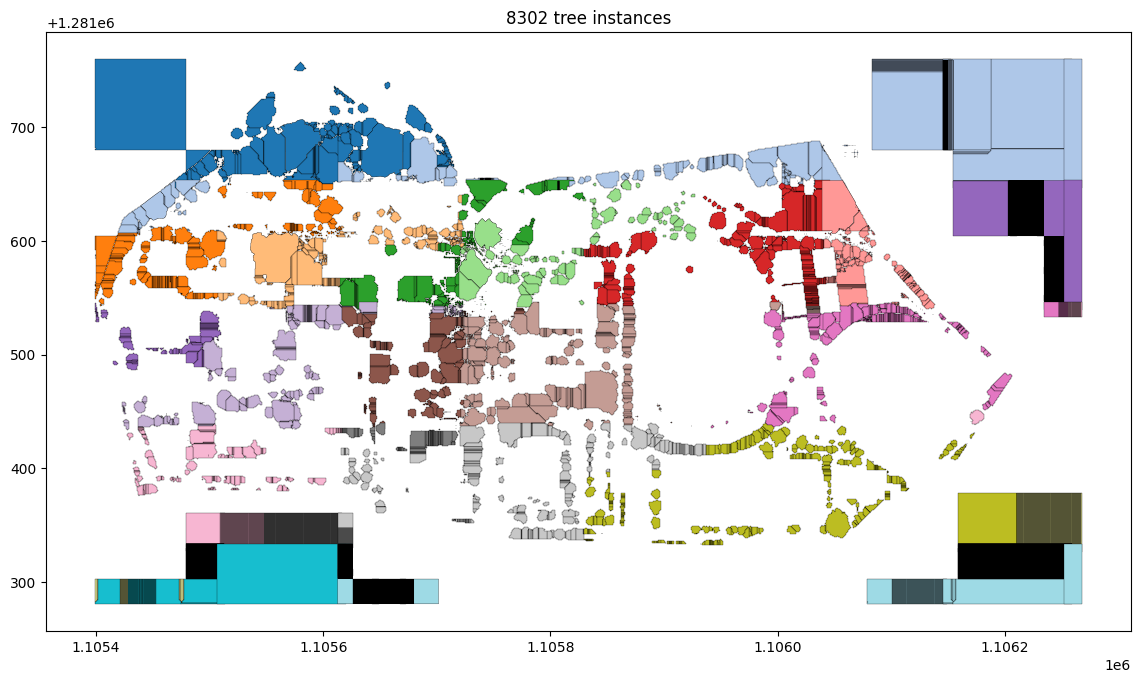

In [ ]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from rasterio.features import rasterize, shapes
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from shapely.geometry import shape, box
import matplotlib.pyplot as plt
from skimage.color import label2rgb

# ============================================================
# CONFIG — adjust these
# ============================================================

trees_gpkg_path = "/content/masks/tree/merged.gpkg"
output_path = "/content/masks/tree/tree_instances.gpkg"

tile_size = 2048     # pixels per processing tile — lower this if you still hit RAM errors (e.g. 1024)
overlap = 128         # pixel overlap between tiles, so crowns aren't cut mid-tree
min_distance = 4      # watershed marker spacing — tune based on your GSD / crown size

# ============================================================
# STEP 1 — load tree polygons
# ============================================================
trees_gdf = gpd.read_file(trees_gpkg_path)
print(f"{len(trees_gdf)} tree polygons loaded")

# ============================================================
# STEP 2 — tiled watershed instancing
# ============================================================
all_instances = []
next_id = 1

with rasterio.open(image_path) as ref:
    H, W = ref.height, ref.width
    full_transform = ref.transform
    crs = ref.crs

    step = tile_size - overlap
    n_tiles_processed = 0

    for row_off in range(0, H, step):
        for col_off in range(0, W, step):
            win_h = min(tile_size, H - row_off)
            win_w = min(tile_size, W - col_off)
            win = Window(col_off, row_off, win_w, win_h)
            win_transform = ref.window_transform(win)

            # only keep polygons that intersect this tile's real-world bounds
            win_bounds = rasterio.windows.bounds(win, full_transform)
            local_geoms = trees_gdf[trees_gdf.intersects(box(*win_bounds))].geometry

            if len(local_geoms) == 0:
                continue

            # rasterize just this tile
            local_mask = rasterize(
                [(geom, 1) for geom in local_geoms],
                out_shape=(win_h, win_w),
                transform=win_transform,
                fill=0,
                dtype="uint8"
            ).astype(bool)

            if not local_mask.any():
                continue

            # watershed split within this tile
            distance = ndi.distance_transform_edt(local_mask)
            coords = peak_local_max(distance, min_distance=min_distance, labels=local_mask)

            if len(coords) == 0:
                continue

            markers_mask = np.zeros(distance.shape, dtype=bool)
            markers_mask[tuple(coords.T)] = True
            markers, _ = ndi.label(markers_mask)
            local_instance_labels = watershed(-distance, markers, mask=local_mask)

            # define this tile's "core" region in real-world coords (excludes the overlap margin)
            # only instances whose centroid falls inside the core are kept from THIS tile —
            # avoids double-counting/duplicating trees that sit in the overlap zone,
            # without ever merging polygons based on adjacency (which would wrongly fuse real neighbors)
            core_col_off = col_off + (overlap // 2 if col_off > 0 else 0)
            core_row_off = row_off + (overlap // 2 if row_off > 0 else 0)
            core_col_end = col_off + win_w - (overlap // 2 if col_off + win_w < W else 0)
            core_row_end = row_off + win_h - (overlap // 2 if row_off + win_h < H else 0)
            core_window = Window(core_col_off, core_row_off,
                                  core_col_end - core_col_off, core_row_end - core_row_off)
            core_bounds = rasterio.windows.bounds(core_window, full_transform)
            core_box = box(*core_bounds)

            # vectorize this tile's instances directly to real-world coords
            for geom, val in shapes(local_instance_labels.astype(np.int32),
                                     mask=local_instance_labels > 0,
                                     transform=win_transform):
                poly = shape(geom)
                if core_box.contains(poly.centroid):   # only keep if this tile "owns" the tree
                    all_instances.append({"geometry": poly, "instance_id": next_id})
                    next_id += 1

            n_tiles_processed += 1

    print(f"Processed {n_tiles_processed} tiles with tree content")

# ============================================================
# STEP 3 — build GeoDataFrame (no merging needed — core-region ownership already prevents duplicates)
# ============================================================
tree_instances_gdf = gpd.GeoDataFrame(all_instances, crs=crs)
tree_instances_gdf["instance_id"] = range(1, len(tree_instances_gdf) + 1)
print(f"{len(tree_instances_gdf)} tree instances")

# ============================================================
# STEP 4 — save
# ============================================================
tree_instances_gdf.to_file(output_path, driver="GPKG")
print(f"Saved to {output_path}")

# ============================================================
# STEP 5 — quick visual sanity check (optional, comment out if not needed)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 12))
tree_instances_gdf.plot(ax=ax, cmap="tab20", edgecolor="black", linewidth=0.2)
ax.set_title(f"{len(tree_instances_gdf)} tree instances")
plt.show()

In [ ]:
from deepforest import main
import numpy as np
from shapely.geometry import box as shapely_box
import geopandas as gpd


model = main.deepforest()
model.load_model("weecology/deepforest-tree")   # replaces use_release()

boxes = model.predict_tile(image_path, patch_size=400, patch_overlap=0.25)

def box_overlaps_mask(row, tree_mask, min_overlap=0.3):
    x1, y1, x2, y2 = int(row.xmin), int(row.ymin), int(row.xmax), int(row.ymax)
    box_area = (x2 - x1) * (y2 - y1)
    if box_area == 0:
        return False
    overlap = tree_mask[y1:y2, x1:x2].sum()
    return (overlap / box_area) >= min_overlap

boxes["keep"] = boxes.apply(lambda r: box_overlaps_mask(r, tree_mask), axis=1)
boxes_filtered = boxes[boxes["keep"]].reset_index(drop=True)
print(f"{len(boxes)} detected -> {len(boxes_filtered)} kept")

geoms = [shapely_box(r.xmin, r.ymin, r.xmax, r.ymax) for _, r in boxes_filtered.iterrows()]
tree_instances_gdf = gpd.GeoDataFrame(
    {"instance_id": range(1, len(geoms) + 1), "score": boxes_filtered["score"].values},
    geometry=geoms,
    crs=ref.crs
)
tree_instances_gdf.to_file("/content/masks/tree/tree_instances_boxes.gpkg", driver="GPKG")

print(f"boxes: {len(boxes)}")
print(f"boxes_filtered: {len(boxes_filtered)}")
boxes.head()

import rasterio
from shapely.geometry import box as shapely_box
import geopandas as gpd

geoms = []
for _, row in boxes_filtered.iterrows():
    # convert pixel (col, row) corners to geographic (x, y) using the transform
    minx, maxy = rasterio.transform.xy(transform, row.ymin, row.xmin)  # top-left
    maxx, miny = rasterio.transform.xy(transform, row.ymax, row.xmax)  # bottom-right
    geoms.append(shapely_box(minx, miny, maxx, maxy))

tree_instances_gdf = gpd.GeoDataFrame(
    {"instance_id": range(1, len(geoms) + 1), "score": boxes_filtered["score"].values},
    geometry=geoms,
    crs=ref.crs
)
tree_instances_gdf.to_file("/content/masks/tree/tree_instances_boxes.gpkg", driver="GPKG")